In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
np.random.seed(42)
normal_data = np.random.normal(50,10,100)
outliers = [150, 200, 250]
data = np.concatenate([normal_data, outliers])
df = pd.DataFrame({"value": data})
print("Original Data")
display(df.describe())

Original Data


,value
count,103.000000
mean,53.360713
std,27.937209
min,23.802549
25%,44.185369
50%,49.279899
75%,55.279137
max,250.000000


Text(0.5, 1.0, 'Histogram with Outlier')

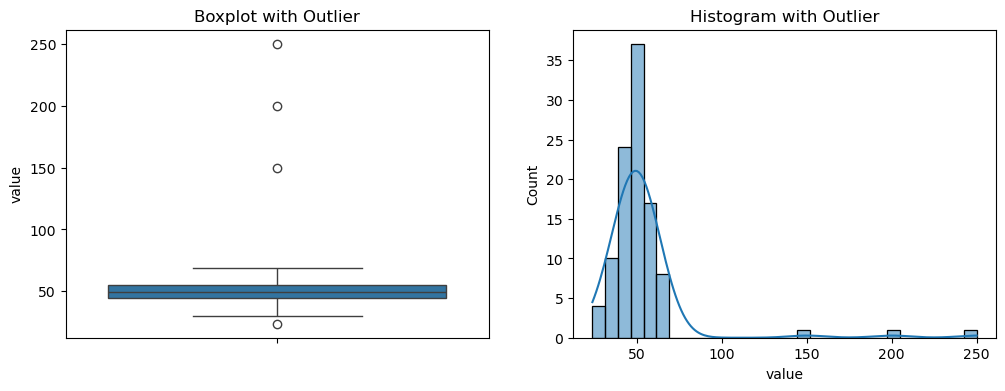

In [4]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.boxplot(y=df['value'])
plt.title("Boxplot with Outlier")

plt.subplot(1,2,2)
sns.histplot(df['value'],bins=30,kde=True)
plt.title("Histogram with Outlier")

In [8]:

### Outlier Detection


# Using Z-Scores
z_scores = np.abs(stats.zscore(df['value']))
df['z_Outlier'] = z_scores > 3

# Using IQR
Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

df['iqr_outlier'] = (df['value']< lower_bound) | (df['value'] > upper_bound)

print("/nOutlier Detection (first 10 rows)")
print(df.tail(10))

/nOutlier Detection (first 10 rows)
          value  z_Outlier  iqr_outlier
93    46.723379      False        False
94    46.078918      False        False
95    35.364851      False        False
96    52.961203      False        False
97    52.610553      False        False
98    50.051135      False        False
99    47.654129      False        False
100  150.000000       True         True
101  200.000000       True         True
102  250.000000       True         True


In [ ]:
# 4. Handling Outliers

# (a) Remove outliers (Iqr method)
df_removed = df[~df['iqr_outlier']]

# (b) Cap Outliers (Winsorisation)
df_capped = df.copy()
df_capped['value'] = np.where(df_capped['value'] > upper_bound, upper_bound, np.where(df_capped['value'] < lower_bound, lower_bound, df_capped['value']))



Text(0.5, 1.0, 'After Capping Outliers')

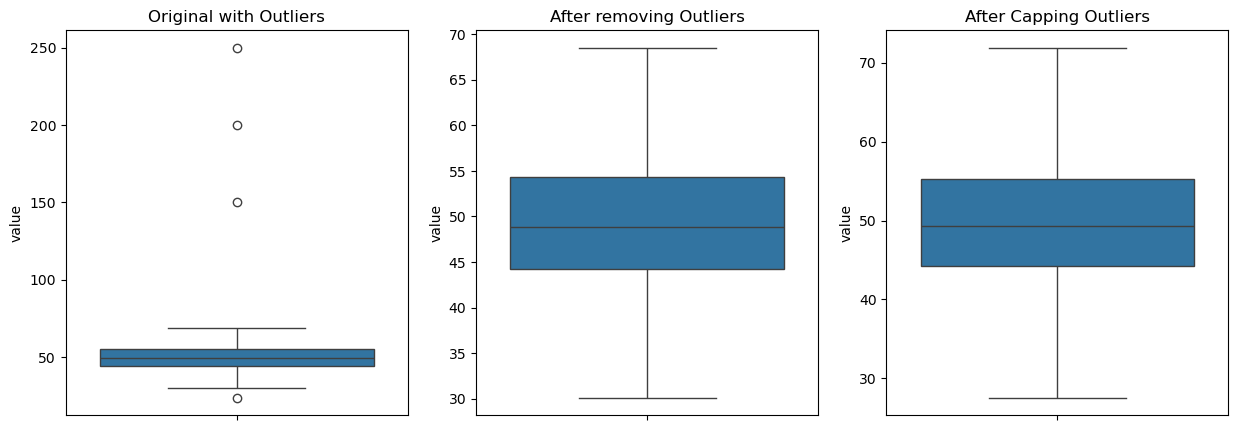

In [15]:
# Visualisation after handling

fig, axes = plt.subplots(1,3,figsize = (15,5))

sns.boxplot(y=df['value'],ax = axes[0])
axes[0].set_title("Original with Outliers")

sns.boxplot(y=df_removed['value'],ax = axes[1])
axes[1].set_title("After removing Outliers")

sns.boxplot(y=df_capped['value'],ax = axes[2])
axes[2].set_title("After Capping Outliers")

